In [ ]:
from  google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


A mask is created to filter out any images with NaN (missing) values across all their dimensions. Only valid data (images and corresponding labels) are retained using this mask.

In [ ]:
import numpy as np

# Load the .npy file using NumPy
data = np.load('/content/drive/MyDrive/Data_set/sampled_cifar10_dataset.npz', allow_pickle=True)
# Check the type of the loaded data
print(type(data))
print(data.files)
x_data = data['images']  # Replace 'x_data' with the actual key for features
y_data = data['labels']

mask = ~np.any(np.isnan(x_data), axis=(1, 2, 3))  # Mask for valid images (no NaN)
x_data = x_data[mask]
y_data = y_data[mask]

print(x_data.shape)
print(y_data.shape)

<class 'numpy.lib.npyio.NpzFile'>
['images', 'labels']
(30000, 32, 32, 3)
(30000,)


Performing essential dataset analysis and preparation. First, it calculates and prints the label frequency in y_data using collections.Counter, then visualizes the class distribution with a bar plot. The script iterates through the .npz file's keys to print their respective shapes for inspection. Finally, it splits the dataset into training (80%) and testing (20%) sets using train_test_split from sklearn, ensuring reproducibility with random_state=42.

Counter({np.int64(2): 3035, np.int64(4): 3035, np.int64(1): 3013, np.int64(8): 3009, np.int64(0): 3009, np.int64(7): 3005, np.int64(3): 2988, np.int64(6): 2984, np.int64(9): 2965, np.int64(5): 2957})


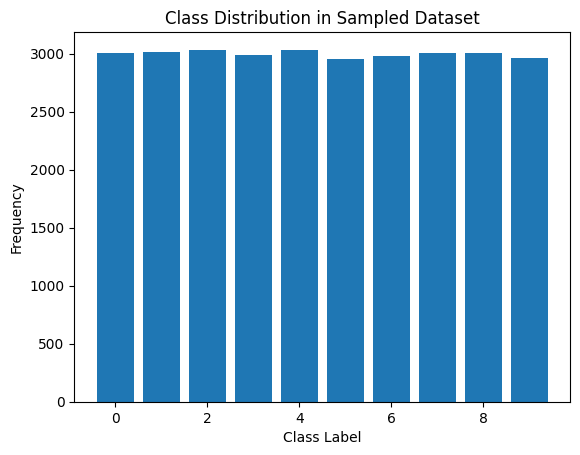

images (30000, 32, 32, 3)
labels (30000,)


In [ ]:

import matplotlib.pyplot as plt
import collections

label_count = collections.Counter(y_data)  # Count the occurrences of each label
print(label_count)

# Plot the class distribution
plt.bar(label_count.keys(), label_count.values())
plt.xlabel("Class Label")
plt.ylabel("Frequency")
plt.title("Class Distribution in Sampled Dataset")
plt.show()
for key in data.files:  # Iterate through keys in the `.npz` file
    print(key, data[key].shape)
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

In [ ]:
# x_train.shape
x_test.shape
# y_train.shape
# y_test.shape

(6000, 32, 32, 3)

In [ ]:
y_train[:5]

array([6, 2, 1, 9, 0])

In [ ]:
classes = ["airplane", "automobile", "bird","cat","deer","dog","frog","horse","ship","truck"]

This function, plot_sample, displays a single image from the dataset along with its corresponding class label. It uses matplotlib to plot the image from x at the specified index and labels it using the class name from the classes list based on the value in y at the same index. The figure size is set to be wide for better visualization.

In [ ]:
import matplotlib.pyplot as plt
def plot_sample(x, y, index):
  plt.figure(figsize = (15,2))
  plt.imshow(x[index])
  plt.xlabel(classes[y[index]])

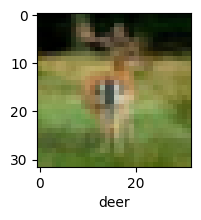

In [ ]:
plot_sample(x_train, y_train, 10)

This code normalizes the pixel values in the training (x_train) and testing (x_test) datasets by dividing them by 255. This scales the pixel values, which range from 0 to 255, to a range of 0 to 1, making the data more suitable for training machine learning models.

In [ ]:
x_train = x_train/255
x_test = x_test/255

This code defines and trains an artificial neural network (ANN) using Keras. The network starts with an input layer for images (shape 32x32x3), flattens it, and passes data through two dense layers (with 3000 and 1000 neurons using ReLU activation). The final dense layer has 10 neurons with a sigmoid activation for classification. The model is compiled with SGD optimizer, sparse categorical cross-entropy loss, and accuracy metric, and trained on x_train and y_train for 5 epochs.

In [ ]:
from keras import models, layers
ann = models.Sequential([
    layers.Input(shape=(32, 32, 3)),  # Define the input layer
    layers.Flatten(),                # Flatten the input
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='sigmoid')
])

ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])
ann.fit(x_train, y_train, epochs=5)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 104ms/step - accuracy: 0.2649 - loss: 2.0268
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 106ms/step - accuracy: 0.3917 - loss: 1.7371
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 72s 93ms/step - accuracy: 0.4241 - loss: 1.6384
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 112ms/step - accuracy: 0.4398 - loss: 1.5813
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 72s 96ms/step - accuracy: 0.4609 - loss: 1.5303


In [ ]:
ann.evaluate(x_test, y_test)

188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4250 - loss: 1.5886


[1.5786904096603394, 0.4336666762828827]

This code evaluates the performance of the trained neural network (ann) on the test set. It predicts the classes for x_test using the model (y_pred) and converts them to class labels (y_pred_classes) by selecting the index of the maximum probability for each prediction. Finally, it generates and prints a classification report, which includes metrics like precision, recall, F1-score, and support for each class.

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(x_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.46      0.56      0.50       600
           1       0.44      0.70      0.54       605
           2       0.36      0.26      0.31       619
           3       0.38      0.25      0.30       604
           4       0.34      0.53      0.42       599
           5       0.30      0.42      0.35       571
           6       0.57      0.36      0.44       640
           7       0.50      0.49      0.49       628
           8       0.64      0.49      0.56       569
           9       0.62      0.26      0.37       565

    accuracy                           0.43      6000
   macro avg       0.46      0.43      0.43      6000
weighted avg       0.46      0.43      0.43      6000



In [ ]:
cnn = models.Sequential([
    #cnn

    layers.Input(shape=(32, 32, 3)),
    # First convolutional block
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second convolutional block
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Fully connected layers

    layers.Flatten(),                # Flatten the input
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [ ]:
cnn.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
            metrics = ['accuracy'])

In [ ]:
cnn.fit(x_train, y_train, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 131s 175ms/step - accuracy: 0.7813 - loss: 0.6268
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 125s 151ms/step - accuracy: 0.7986 - loss: 0.5785
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 153ms/step - accuracy: 0.7990 - loss: 0.5651
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 152ms/step - accuracy: 0.8105 - loss: 0.5272
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 140s 149ms/step - accuracy: 0.8154 - loss: 0.5234
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 147ms/step - accuracy: 0.8240 - loss: 0.5001
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 112s 150ms/step - accuracy: 0.8385 - loss: 0.4558
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 111s 148ms/step - accuracy: 0.8358 - loss: 0.4581
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 112s 150ms/step - accuracy: 0.8499 - loss: 0.4167
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 149ms/step - accuracy: 0.8505 - loss: 0.4143


In [ ]:
cnn.evaluate(x_test, y_test)

188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.7618 - loss: 0.7460


[0.7415187358856201, 0.7651666402816772]

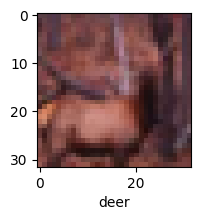

In [ ]:
plot_sample(x_test, y_test, 3)

In [ ]:
y_pred = cnn.predict(x_test)
y_pred[:5]

188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step


array([[3.42628908e-07, 2.43147906e-06, 7.33082707e-05, 3.00763175e-04,
        6.00679050e-05, 5.29356294e-05, 9.99398112e-01, 2.24123742e-08,
        1.10577501e-04, 1.54388044e-06],
       [1.09309382e-04, 5.60857305e-10, 9.98400033e-01, 1.62838489e-06,
        2.96281513e-07, 3.46738234e-05, 1.43923378e-03, 1.47036089e-05,
        6.62229560e-09, 1.23371535e-08],
       [2.26053930e-06, 1.77324811e-12, 9.99988854e-01, 4.11977936e-07,
        3.33835715e-06, 2.87514717e-06, 1.80483380e-06, 1.65025043e-08,
        3.05835329e-07, 1.71499659e-09],
       [7.80034861e-06, 6.71931775e-03, 6.37077494e-03, 5.73726118e-01,
        1.47873223e-01, 1.49471864e-01, 3.22278822e-03, 1.03192873e-01,
        1.02379519e-04, 9.31286160e-03],
       [6.71396556e-04, 8.63666537e-06, 1.64302476e-02, 3.93935591e-01,
        5.91739372e-04, 5.83714604e-01, 3.21757025e-03, 1.28623121e-03,
        1.29817490e-05, 1.30918226e-04]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:10]

[np.int64(6),
 np.int64(2),
 np.int64(2),
 np.int64(3),
 np.int64(5),
 np.int64(7),
 np.int64(6),
 np.int64(8),
 np.int64(9),
 np.int64(8)]

In [ ]:
y_test[:15]

array([6, 6, 2, 4, 5, 4, 6, 8, 9, 8, 9, 4, 5, 6, 6])

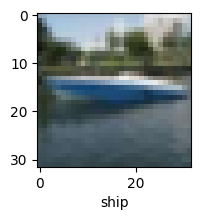

In [ ]:
plot_sample(x_test, y_test,7)

In [ ]:
classes[y_classes[7]]

'ship'